# Análise Avançada: Generalization Gap & Sharpness (YOLO)\n
\n
Neste notebook, realizamos uma análise completa comparando modelos YOLO treinados com **Small Batch (16)** e **Large Batch (128)**.\n
\n
**Análises Realizadas:**\n
1. **Histórico de Treinamento:** Comparação das curvas de Loss (Treino vs Validação) para visualizar overfitting.\n
2. **Generalization Gap Real:** Diferença entre mAP no conjunto de Treino (`split='train'`) e Validação (`split='val'`).\n
3. **Sharpness (Sensibilidade a Ruído):** Impacto de perturbações nos pesos na performance do modelo.

In [60]:
import ultralytics 
from ultralytics import YOLO 
import torch 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import copy 
import yaml 
import os 
 
# Configuração 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Device: {device}") 
 
# Garantir data_local.yaml 
data_config = { 
    'path': os.path.abspath('treino_transitar'), 
    'train': 'train', 
    'val': 'valid', 
    'test': 'test', 
    'names': {0: 'pessoa', 1: 'bicicleta', 2: 'carro', 3: 'moto', 4: '-', 5: 'onibus', 6: 'van', 7: 'onibus'} 
} 
with open('data_local.yaml', 'w') as f: 
    yaml.dump(data_config, f) 
 
# Carregar Modelos 
model_sb = YOLO('batch16/weights/best.pt')     # Batch 16 
model_lb = YOLO('batch128/weights/best.pt') # Batch 128

Device: cuda


In [61]:
# --- Visualização da Topologia da Rede ---
print("Topologia do Modelo (Small Batch):")
print(model_sb)
# Nota: A topologia é a mesma para o Large Batch, apenas os pesos diferem.


Topologia do Modelo (Small Batch):
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentu

In [62]:
## 1. Análise do Histórico de Treinamento (Loss Curves) 
print("Carregando histórico de treinamento...") 
try: 
    df_sb = pd.read_csv('batch16/results.csv') 
    df_lb = pd.read_csv('batch128/results.csv') 
     
    # Limpar nomes das colunas (remover espaços) 
    df_sb.columns = df_sb.columns.str.strip() 
    df_lb.columns = df_lb.columns.str.strip() 
     
    print("Colunas encontradas:", df_sb.columns.tolist()) 
     
    has_history = True 
except Exception as e: 
    print(f"Erro ao carregar histórico: {e}") 
    has_history = False

Carregando histórico de treinamento...
Colunas encontradas: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


In [63]:
## 2. Cálculo do Generalization Gap (Train mAP vs Val mAP) 
 
def get_map(model, split='val'): 
    print(f"Avaliando modelo em split='{split}'...") 
    # verbose=False para menos log 
    results = model.val(data='data_local.yaml', split=split, verbose=False, plots=False) 
    return results.box.map 
 
print(" >>> Calculando mAP para Small Batch (Batch 16)...") 
sb_val_map = get_map(model_sb, 'val') 
sb_train_map = get_map(model_sb, 'train') # Pode demorar um pouco 
 
print(" >>> Calculando mAP para Large Batch (Batch 128)...") 
lb_val_map = get_map(model_lb, 'val') 
lb_train_map = get_map(model_lb, 'train') 
 
sb_gap = sb_train_map - sb_val_map 
lb_gap = lb_train_map - lb_val_map 
 
print(f" Small Batch: Train={sb_train_map:.4f}, Val={sb_val_map:.4f}, Gap={sb_gap:.4f}") 
print(f"Large Batch: Train={lb_train_map:.4f}, Val={lb_val_map:.4f}, Gap={lb_gap:.4f}")

 >>> Calculando mAP para Small Batch (Batch 16)...
Avaliando modelo em split='val'...
Ultralytics 8.3.235 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11871MiB)
YOLOv12n summary (fused): 159 layers, 2,558,288 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7146.8±1191.8 MB/s, size: 362.1 KB)
val: Scanning /home/luan/projeto-final/treino_transitar/valid/labels.cache... 3353 images, 0 backgrounds, 294 corrupt: 100% ━━━━━━━━━━━━ 3353/3353 10.2Mit/s 0.0s
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0178-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0809-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame1051-roi1.png: ignor

In [64]:
## 3. Análise de Sharpness 
 
def calculate_sharpness_score(model_path, data_yaml, epsilon=5e-3, num_samples=5): 
    model = YOLO(model_path) 
    base_map = model.val(data=data_yaml, verbose=False, plots=False).box.map 
     
    map_drops = [] 
    for _ in range(num_samples): 
        model_p = YOLO(model_path) 
        state = model_p.model.state_dict() 
        with torch.no_grad(): 
            for k in state: 
                if state[k].dtype.is_floating_point: 
                    noise = torch.randn_like(state[k]) * epsilon * (state[k].abs() + 1e-6) 
                    state[k].add_(noise) 
         
        curr_map = model_p.val(data=data_yaml, verbose=False, plots=False).box.map 
        map_drops.append(base_map - curr_map) 
     
    avg_drop = np.mean(map_drops) 
    return avg_drop, (avg_drop / (base_map + 1e-6)) * 100 
 
print(" >>> Calculando Sharpness...") 
_, sb_sharpness = calculate_sharpness_score('batch16/weights/best.pt', 'data_local.yaml') 
_, lb_sharpness = calculate_sharpness_score('batch128/weights/best.pt', 'data_local.yaml') 
 
print(f"SB Sharpness Score: {sb_sharpness:.2f}%") 
print(f"LB Sharpness Score: {lb_sharpness:.2f}%")

 >>> Calculando Sharpness...
Ultralytics 8.3.235 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11871MiB)
YOLOv12n summary (fused): 159 layers, 2,558,288 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9027.2±1403.9 MB/s, size: 1279.5 KB)
val: Scanning /home/luan/projeto-final/treino_transitar/valid/labels.cache... 3353 images, 0 backgrounds, 294 corrupt: 100% ━━━━━━━━━━━━ 3353/3353 10.2Mit/s 0.0s
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0178-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0809-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame1051-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset c

Salvando gráfico de Loss em 'results_loss.png'...


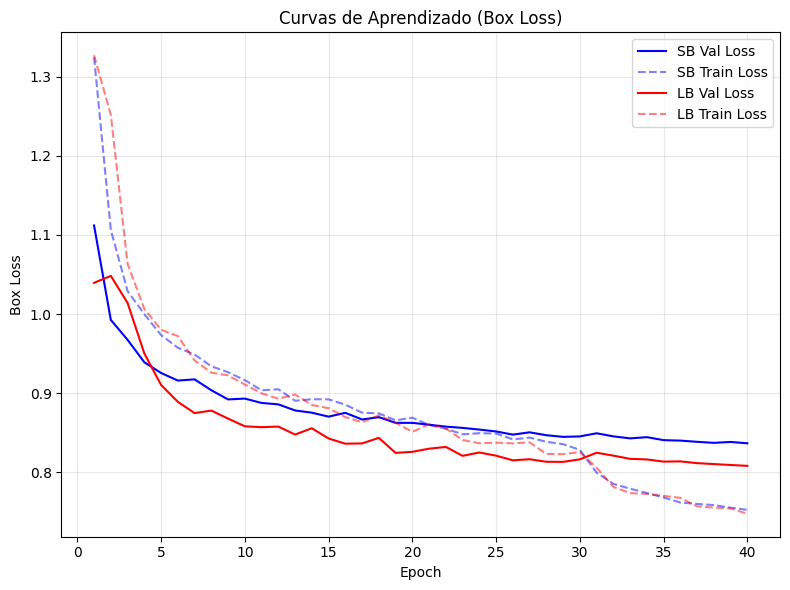

Salvando gráfico de Gap em 'results_gap.png'...


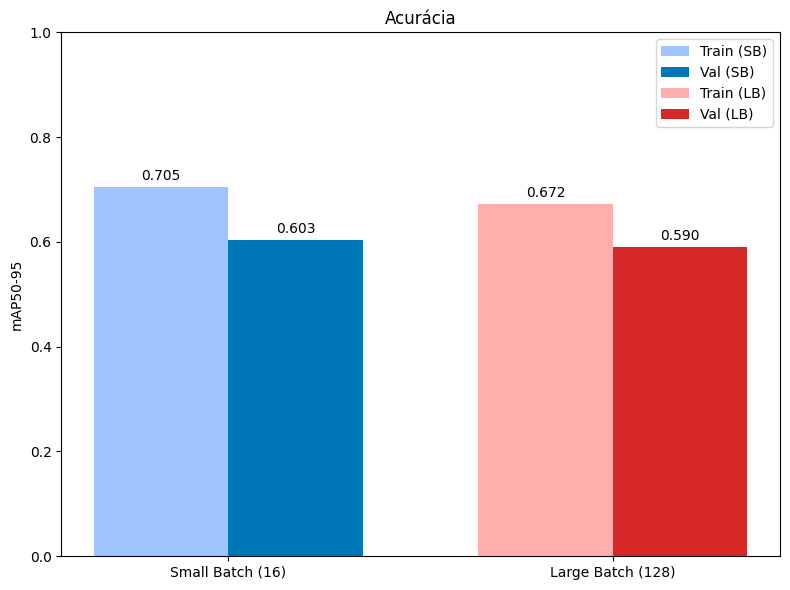

Salvando gráfico de Sharpness em 'results_sharpness.png'...


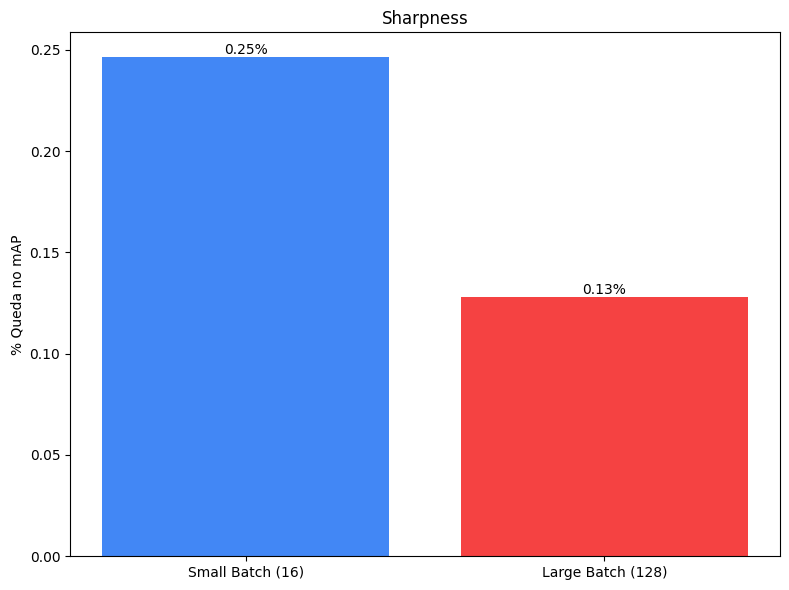

In [65]:
## 4. Visualização e Salvamento dos Resultados 
 
# --- Plot 1: Loss Curves --- 
plt.figure(figsize=(8, 6)) 
if has_history: 
    plt.plot(df_sb['epoch'], df_sb['val/box_loss'], 'b-', label='SB Val Loss') 
    plt.plot(df_sb['epoch'], df_sb['train/box_loss'], 'b--', label='SB Train Loss', alpha=0.5) 
    plt.plot(df_lb['epoch'], df_lb['val/box_loss'], 'r-', label='LB Val Loss') 
    plt.plot(df_lb['epoch'], df_lb['train/box_loss'], 'r--', label='LB Train Loss', alpha=0.5) 
    plt.title('Curvas de Aprendizado (Box Loss)') 
    plt.xlabel('Epoch') 
    plt.ylabel('Box Loss') 
    plt.legend() 
    plt.grid(True, alpha=0.3) 
else: 
    plt.text(0.5, 0.5, 'Histórico não encontrado', ha='center') 
 
plt.tight_layout() 
print("Salvando gráfico de Loss em 'results_loss.png'...") 
plt.savefig('results_loss.png', dpi=300) 
plt.show() 
 
# --- Plot 2: Generalization Gap --- 
plt.figure(figsize=(8, 6)) 
x = np.arange(2) 
width = 0.35 
train_vals = [sb_train_map, lb_train_map] 
val_vals = [sb_val_map, lb_val_map] 
 
rects1 = plt.bar(x - width/2, train_vals, width, label='Train mAP', color=['#a0c4ff', '#ffadad']) 
rects2 = plt.bar(x + width/2, val_vals, width, label='Val mAP', color=['#0077b6', '#d62828']) 
 
from matplotlib.patches import Patch 
legend_elements = [ 
    Patch(facecolor='#a0c4ff', label='Train (SB)'), 
    Patch(facecolor='#0077b6', label='Val (SB)'), 
    Patch(facecolor='#ffadad', label='Train (LB)'), 
    Patch(facecolor='#d62828', label='Val (LB)') 
] 
plt.legend(handles=legend_elements) 
 
plt.ylabel('mAP50-95') 
plt.title(f'Acurácia') 
plt.xticks(x, ['Small Batch (16)', 'Large Batch (128)']) 
 
plt.bar_label(rects1, padding=3, fmt='%.3f') 
plt.bar_label(rects2, padding=3, fmt='%.3f') 
plt.ylim(0, 1.0) 
 
plt.tight_layout() 
print("Salvando gráfico de Gap em 'results_gap.png'...") 
plt.savefig('results_gap.png', dpi=300) 
plt.show() 
# --- Plot 3: Sharpness --- 
plt.figure(figsize=(8, 6)) 
scores = [sb_sharpness, lb_sharpness] 
bars = plt.bar(['Small Batch (16)', 'Large Batch (128)'], scores, color=['#4287f5', '#f54242']) 
plt.title('Sharpness') 
plt.ylabel('% Queda no mAP') 
plt.bar_label(bars, fmt='%.2f%%') 
 
plt.tight_layout() 
print("Salvando gráfico de Sharpness em 'results_sharpness.png'...") 
plt.savefig('results_sharpness.png', dpi=300) 
plt.show()

In [67]:
# --- Análise da Superfície de Solução 1D (Interpolação Linear) ---
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt

def interpolate_weights(model_a, model_b, alpha):
    """Retorna um novo estado de modelo com pesos interpolados: (1-alpha)*A + alpha*B"""
    sd_a = model_a.model.state_dict()
    sd_b = model_b.model.state_dict()
    sd_interp = {}
    for key in sd_a:
        sd_interp[key] = (1 - alpha) * sd_a[key] + alpha * sd_b[key]
    return sd_interp

# Intervalo de alpha para explorar (de -0.5 a 1.5)
alphas = np.linspace(-0.5, 1.5, 21)
losses = []
maps = []

print("Iniciando varredura de interpolação...")

# Modelo temporário para carregar pesos interpolados
# Modelo temporário clonado do SB para garantir compatibilidade de chaves (Fusion)
temp_model = copy.deepcopy(model_sb) 

for alpha in alphas:
    print(f"Avalíando alpha = {alpha:.2f}...")
    
    # Interpolar pesos
    new_state_dict = interpolate_weights(model_sb, model_lb, alpha)
    temp_model.model.load_state_dict(new_state_dict)
    
    # Avaliar
    # verbose=False para reduzir log, plots=False para não gerar gráficos a cada passo
    results = temp_model.val(data='data_local.yaml', split='val', verbose=False, plots=False)
    
    losses.append(results.box.loss if hasattr(results.box, 'loss') else results.speed['inference']) # Fallback se loss não direto, mas geralmente results.box.map é o foco. 
    # Correction: model.val() return results object. accessing loss might be tricky directly as metric. 
    # Let's focus on mAP first as it is standard, or check validation results attributes.
    # Ultralytics results object usually has .maps or .box.map
    maps.append(results.box.map)

print("Varredura concluída.")

Iniciando varredura de interpolação...
Avalíando alpha = -0.50...
Ultralytics 8.3.235 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11871MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5718.4±1331.3 MB/s, size: 508.2 KB)
val: Scanning /home/luan/projeto-final/treino_transitar/valid/labels.cache... 3353 images, 0 backgrounds, 294 corrupt: 100% ━━━━━━━━━━━━ 3353/3353 9.3Mit/s 0.0s
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0178-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame0809-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: /home/luan/projeto-final/treino_transitar/valid/images/115.avi-frame1051-roi1.png: ignoring corrupt image/label: Label class 7 exceeds dataset class count 7. Possible class labels are 0-6
val: 

Salvando gráfico de superfície em 'results_surface.png'...


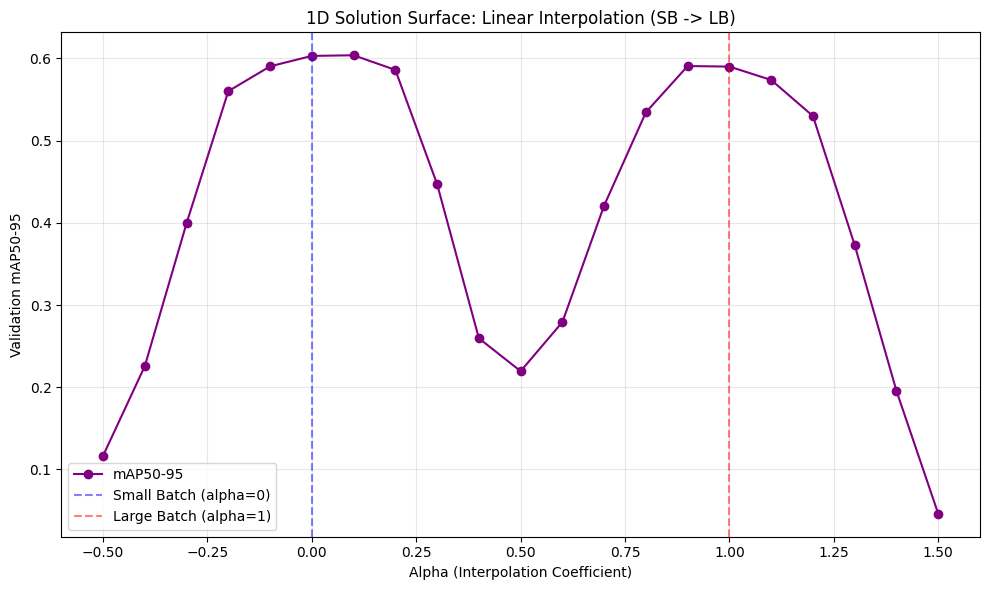

In [68]:
# --- Plot da Superfície 1D ---
plt.figure(figsize=(10, 6))
plt.plot(alphas, maps, 'o-', color='purple', label='mAP50-95')

# Destacar SB (alpha=0) e LB (alpha=1)
plt.axvline(0, color='blue', linestyle='--', alpha=0.5, label='Small Batch (alpha=0)')
plt.axvline(1, color='red', linestyle='--', alpha=0.5, label='Large Batch (alpha=1)')

plt.title('1D Solution Surface: Linear Interpolation (SB -> LB)')
plt.xlabel('Alpha (Interpolation Coefficient)')
plt.ylabel('Validation mAP50-95')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
print("Salvando gráfico de superfície em 'results_surface.png'...")
plt.savefig('results_surface.png', dpi=300)
plt.show()

In [ ]:
# --- Visualização de Predição Aleatória ---
import random
import glob
import os
import cv2
import matplotlib.pyplot as plt

# Caminho para imagens de validação
val_images_path = 'treino_transitar/valid/images'
image_files = glob.glob(os.path.join(val_images_path, '*.png')) + glob.glob(os.path.join(val_images_path, '*.jpg'))

if len(image_files) > 0:
    # Escolher imagem aleatória
    random_image_path = random.choice(image_files)
    print(f"Predizendo imagem: {random_image_path}")
    
    # Realizar inferência (usando modelo Small Batch)
    results = model_sb(random_image_path)
    
    # Plotar resultado
    # results[0].plot() retorna array BGR
    res_plotted = results[0].plot()
    
    # Exibir
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predição YOLO (Small Batch) - {os.path.basename(random_image_path)}")
    plt.show()
else:
    print(f"Nenhuma imagem encontrada em {val_images_path}")